In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import weibull_min



# --- 2. 找到所有以 Run 开头的 csv 文件 ---
files = glob.glob('../../dataset/slice_data/Run*.csv') # 自动匹配 Run1.csv, Run2.csv 等
files.sort() # 排序确保顺序一致

print(f"找到 {len(files)} 个文件：{files}")

找到 5 个文件：['../../dataset/slice_data\\Run10_slice_z.csv', '../../dataset/slice_data\\Run11_slice_z.csv', '../../dataset/slice_data\\Run12_slice_z.csv', '../../dataset/slice_data\\Run1_slice_z.csv', '../../dataset/slice_data\\Run2_slice_z.csv']



全局拟合结果: k=1.266, c=0.316, n=34291

WEIBULL分布参数汇总
+------------+--------------+--------------+------------+------------+--------------+
| 数据集     |   形状参数 k |   尺度参数 c |   数据点数 |   平均速度 |   速度标准差 |
+============+==============+==============+============+============+==============+
| LCZ 8      |        2.125 |        0.510 |       6925 |      0.423 |        0.251 |
+------------+--------------+--------------+------------+------------+--------------+
| LCZ 7      |        1.149 |        0.183 |       9737 |      0.167 |        0.177 |
+------------+--------------+--------------+------------+------------+--------------+
| LCZ 10     |        1.097 |        0.377 |       4367 |      0.359 |        0.336 |
+------------+--------------+--------------+------------+------------+--------------+
| LCZ 6      |        1.442 |        0.307 |      13262 |      0.267 |        0.201 |
+------------+--------------+--------------+------------+------------+--------------+
| Global Fit |        1.266 

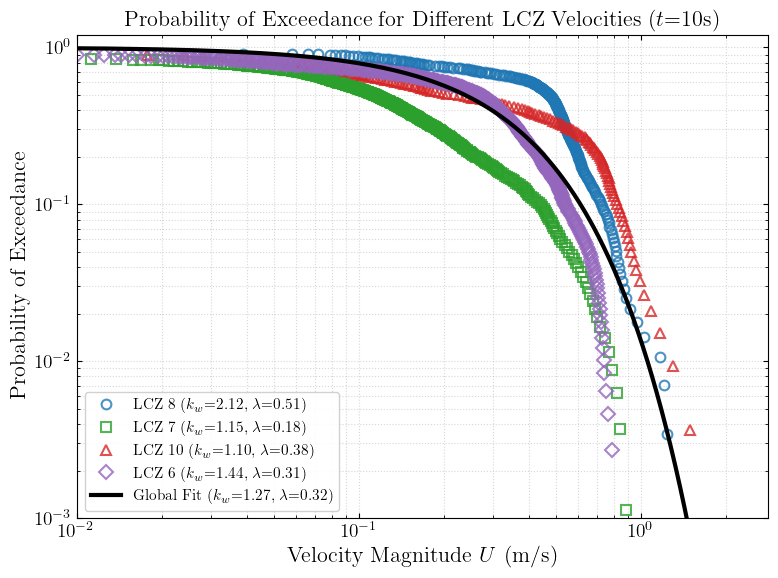

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import weibull_min
from tabulate import tabulate  # 用于美观地输出表格

# 如果没有tabulate，可以安装：pip install tabulate
# 或者使用替代方案（见代码中的注释）

# --- 1. 基础配置 ---
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'text.usetex': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True
})

# 定义 Run 编号与图例名称的映射关系
label_map = {
    'Run2': 'LCZ 6',
    'Run10': 'LCZ 8',
    'Run11': 'LCZ 7',
    'Run12': 'LCZ 10'
}

files = glob.glob('../../dataset/slice_data/Run*.csv') 
files.sort()
target_time = 10 

all_u_mag_for_fit = []
# 适用于科学出版物的配色
scientific_colors = {
    'blue': '#1f77b4',
    'orange': '#ff7f0e',
    'green': '#2ca02c',
    'red': '#d62728',
    'purple': '#9467bd',
    'brown': '#8c564b',
    'pink': '#e377c2',
    'gray': '#7f7f7f',
    'yellow': '#bcbd22',
    'cyan': '#17becf',
}

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

plt.figure(figsize=(8, 6))  # 稍微增大图形尺寸以容纳更多信息

# 存储每个数据集的Weibull参数
weibull_params = []

# --- 2. 循环处理每个文件 ---
for idx, file in enumerate(files):
    try:
        # 提取纯文件名
        base_name = os.path.basename(file).split('_')[0]
        
        # 根据映射表获取图例名
        display_label = label_map.get(base_name, base_name)
        
        df = pd.read_csv(file, usecols=['Time', 'U:0', 'U:1', 'U:2'])
        subset = df[df['Time'] == target_time].dropna()
        
        if not subset.empty:
            u_mag = np.sqrt(subset['U:0']**2 + subset['U:1']**2 + subset['U:2']**2).values
            all_u_mag_for_fit.append(u_mag)
            
            data_sorted = np.sort(u_mag)
            n_single = len(data_sorted)
            p_exceed = 1.0 - (np.arange(1, n_single + 1) / n_single)
            mask = p_exceed > 0
            
            # --- 对每个数据集进行单独的Weibull拟合 ---
            try:
                # 拟合Weibull分布（floc=0表示固定位置参数为0）
                shape_k, loc, scale_c = weibull_min.fit(u_mag, floc=0)
                
                # 计算拟合曲线
                x_fit_single = np.linspace(data_sorted.min(), data_sorted.max(), 100)
                y_fit_single = 1.0 - weibull_min.cdf(x_fit_single, shape_k, loc=0, scale=scale_c)
                
                # 存储参数
                weibull_params.append({
                    'label': display_label,
                    'base_name': base_name,
                    'shape_k': shape_k,
                    'scale_c': scale_c,
                    'n_points': n_single,
                    'mean_vel': np.mean(u_mag),
                    'std_vel': np.std(u_mag)
                })
                
                # 绘制散点
                plt.plot(data_sorted[mask], p_exceed[mask], 
                         color=colors[idx % len(colors)], 
                         marker=markers[idx % len(markers)], 
                         linestyle='none', 
                         markersize=7, 
                         alpha=0.8,
                         markerfacecolor='none',
                         markeredgewidth=1.5,
                         label=fr'{display_label} ($k_w$={shape_k:.2f}, $\lambda$={scale_c:.2f})',
                         markevery=25 if n_single > 100 else 5)
                '''
                # 可选：绘制每个数据集的拟合曲线（用虚线）
                plt.plot(x_fit_single, y_fit_single, 
                         color=colors[idx % len(colors)], 
                         linestyle='--', 
                         alpha=0.5,
                         linewidth=1.5)
                
                print(f" - {display_label} ({base_name}): k={shape_k:.3f}, c={scale_c:.3f}, n={n_single}")
               ''' 
            except Exception as fit_err:
                print(f" - {display_label} Weibull拟合失败: {fit_err}")
                # 如果拟合失败，仍然绘制散点但不显示参数
                plt.plot(data_sorted[mask], p_exceed[mask], 
                         color=colors[idx % len(colors)], 
                         marker=markers[idx % len(markers)], 
                         linestyle='none', 
                         markersize=10, 
                         alpha=0.8,
                         markerfacecolor='white',
                         label=display_label,
                         markevery=25 if n_single > 100 else 5)
                
    except Exception as e:
        print(f"读取 {file} 失败: {e}")

# --- 3. 进行全局合并拟合 ---
if all_u_mag_for_fit:
    combined_data = np.concatenate(all_u_mag_for_fit)
    try:
        shape, loc, scale = weibull_min.fit(combined_data, floc=0)
        x_all = np.sort(combined_data)
        x_fit = np.linspace(x_all.min(), x_all.max(), 300)
        y_fit = 1.0 - weibull_min.cdf(x_fit, shape, loc=0, scale=scale)
        
        # 将全局拟合参数也存储
        weibull_params.append({
            'label': 'Global Fit',
            'base_name': 'ALL',
            'shape_k': shape,
            'scale_c': scale,
            'n_points': len(combined_data),
            'mean_vel': np.mean(combined_data),
            'std_vel': np.std(combined_data)
        })
        
        plt.plot(x_fit, y_fit, 'k-', linewidth=3, 
                 label=fr'Global Fit ($k_w$={shape:.2f}, $\lambda$={scale:.2f})')
        
        print(f"\n全局拟合结果: k={shape:.3f}, c={scale:.3f}, n={len(combined_data)}")
        
    except Exception as e:
        print(f"全局拟合失败: {e}")

# --- 4. 输出Weibull参数表格 ---
print("\n" + "="*60)
print("WEIBULL分布参数汇总")
print("="*60)

if weibull_params:
    # 准备表格数据
    table_data = []
    for params in weibull_params:
        table_data.append([
            params['label'],
            params['shape_k'],
            params['scale_c'],
            params['n_points'],
            f"{params['mean_vel']:.3f}",
            f"{params['std_vel']:.3f}"
        ])
    
    # 使用tabulate输出美观的表格
    try:
        headers = ["数据集", "形状参数 k", "尺度参数 c", "数据点数", "平均速度", "速度标准差"]
        print(tabulate(table_data, headers=headers, tablefmt="grid", floatfmt=".3f"))
    except:
        # 如果tabulate不可用，使用简单格式
        print(f"{'数据集':<15} {'k':<10} {'c':<10} {'n':<10} {'均值':<10} {'标准差':<10}")
        print("-" * 65)
        for params in weibull_params:
            print(f"{params['label']:<15} {params['shape_k']:<10.3f} {params['scale_c']:<10.3f} "
                  f"{params['n_points']:<10} {params['mean_vel']:<10.3f} {params['std_vel']:<10.3f}")

# --- 5. 图表细节美化 ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Velocity Magnitude $U$ (m/s)', fontsize=16)
plt.ylabel('Probability of Exceedance', fontsize=16)
plt.title(f'Probability of Exceedance for Different LCZ Velocities ($t$={target_time}s)', fontsize=16)

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.xlim(1e-2)
plt.ylim(1e-3, 1.2)

# 调整图例位置和大小
plt.legend(loc='best', ncol=1, fontsize=11, framealpha=0.9)
plt.tight_layout()

# --- 6. 可选：保存参数到CSV文件 ---
if weibull_params:
    params_df = pd.DataFrame(weibull_params)
    params_df.to_csv(f'weibull_parameters_t{target_time}.csv', index=False)
    print(f"\n参数已保存到: weibull_parameters_t{target_time}.csv")

plt.savefig(f'Weibull_Exceedance_t{target_time}.jpg', dpi=600, bbox_inches='tight')

plt.show()